## Data Collection

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.max_columns', 30)

In [2]:
df1 = pd.read_csv('data.csv')
df2 = pd.read_csv('collegiate_athlete_injury_dataset (1).csv')

print("Dataset 1 (Athlete Injury & Performance)")
print(f"  Shape : {df1.shape}")
print(f"  Columns: {df1.columns.tolist()}")

print("\nDataset 2 (University Football Injury)")
print(f"  Shape : {df2.shape}")
print(f"  Columns: {df2.columns.tolist()}")

Dataset 1 (Athlete Injury & Performance)
  Shape : (800, 19)
  Columns: ['Age', 'Height_cm', 'Weight_kg', 'Position', 'Training_Hours_Per_Week', 'Matches_Played_Past_Season', 'Previous_Injury_Count', 'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms', 'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score', 'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score', 'Warmup_Routine_Adherence', 'Injury_Next_Season', 'BMI']

Dataset 2 (University Football Injury)
  Shape : (200, 17)
  Columns: ['Athlete_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'Position', 'Training_Intensity', 'Training_Hours_Per_Week', 'Recovery_Days_Per_Week', 'Match_Count_Per_Week', 'Rest_Between_Events_Days', 'Fatigue_Score', 'Performance_Score', 'Team_Contribution_Score', 'Load_Balance_Score', 'ACL_Risk_Score', 'Injury_Indicator']


In [3]:
df1.head(10)

,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932
5,23,189,89,Goalkeeper,10.262987,31,2,78.450720,80.927984,265.801623,81.106339,6.354870,86.418954,8.538027,39.929697,74.982476,1,0,24.915316
6,22,189,71,Midfielder,8.069288,5,4,63.045009,75.032030,269.099907,76.787369,6.458297,65.179995,7.339327,75.039112,65.790192,0,1,19.876263
7,23,184,75,Goalkeeper,6.407939,26,0,77.566677,76.947213,226.966431,93.317382,6.161460,79.260417,8.072895,25.783371,89.782578,0,0,22.152647
8,22,174,71,Midfielder,10.554931,23,0,78.877905,89.584501,240.745054,80.898575,6.199281,77.152290,7.661190,52.581600,78.587201,1,0,23.450918
9,23,185,76,Midfielder,11.899732,22,0,83.194761,82.244364,259.628161,89.077577,6.206694,90.396480,6.035505,55.049722,83.947949,1,0,22.205990


In [4]:
df2.head(10)

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Position,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
0,A001,24,Female,195,99,Center,2,13,2,3,1,1,99,58,100,4,0
1,A002,21,Male,192,65,Forward,8,14,1,3,1,4,55,63,83,73,0
2,A003,22,Male,163,83,Guard,8,8,2,1,3,6,58,62,100,62,0
3,A004,24,Female,192,90,Guard,1,13,1,1,1,7,82,74,78,51,0
4,A005,20,Female,173,79,Center,3,9,1,2,1,2,90,51,83,49,0
5,A006,22,Female,180,75,Guard,9,14,3,4,1,6,74,84,99,54,0
6,A007,22,Female,179,90,Forward,5,13,1,4,2,7,97,56,78,84,1
7,A008,24,Female,167,64,Center,6,7,2,3,3,2,62,70,100,42,0
8,A009,19,Female,166,91,Guard,4,19,2,3,3,2,58,67,80,50,0
9,A010,20,Female,162,63,Center,2,8,3,3,2,7,62,52,100,35,0


In [5]:
# standarisasi nama kolom
df1.columns = df1.columns.str.lower().str.strip()
df2.columns = df2.columns.str.lower().str.strip()

# kolom bersama yang akan dipertahankan
common_cols = ['age', 'height_cm', 'weight_kg', 'position', 'training_hours_per_week']

# kolom df1 yang relevan
cols_df1 = common_cols + [
    'previous_injury_count', 'knee_strength_score', 'hamstring_flexibility',
    'reaction_time_ms', 'balance_test_score', 'sprint_speed_10m_s',
    'agility_score', 'sleep_hours_per_night', 'stress_level_score',
    'nutrition_quality_score', 'warmup_routine_adherence', 'injury_next_season', 'bmi'
]

# kolom df2 yang relevan
cols_df2 = common_cols + [
    'recovery_days_per_week', 'fatigue_score', 'performance_score',
    'load_balance_score', 'acl_risk_score', 'injury_indicator'
]

df1_sub = df1[cols_df1].copy()
df2_sub = df2[cols_df2].copy()

df1_sub.rename(columns={'injury_next_season': 'injury_indicator'}, inplace=True)

# menambahkan kolom source
df1_sub['source'] = 'athlete_performance'
df2_sub['source'] = 'univ_football'

# gabungkan dengan outer concat, kolom yang tidak ada akan jadi NaN
df = pd.concat([df1_sub, df2_sub], ignore_index=True, sort=False)

# menggabungkan posisi yang sama
position_remap = {
    'Guard'   : 'Defender',
    'Center'  : 'Midfielder',
}
df['position'] = df['position'].replace(position_remap)

print("Posisi setelah penyeragaman:")
print(df['position'].value_counts())

print(f"Dataset gabungan: {df.shape}")
print(f"  - Dari dataset 1 : {len(df1_sub)} baris")
print(f"  - Dari dataset 2 : {len(df2_sub)} baris")
print()
print(df.dtypes)

Posisi setelah penyeragaman:
position
Midfielder    279
Defender      268
Forward       267
Goalkeeper    186
Name: count, dtype: int64
Dataset gabungan: (1000, 24)
  - Dari dataset 1 : 800 baris
  - Dari dataset 2 : 200 baris

age                           int64
height_cm                     int64
weight_kg                     int64
position                     object
training_hours_per_week     float64
previous_injury_count       float64
knee_strength_score         float64
hamstring_flexibility       float64
reaction_time_ms            float64
balance_test_score          float64
sprint_speed_10m_s          float64
agility_score               float64
sleep_hours_per_night       float64
stress_level_score          float64
nutrition_quality_score     float64
warmup_routine_adherence    float64
injury_indicator              int64
bmi                         float64
source                       object
recovery_days_per_week      float64
fatigue_score               float64
performance_scor

In [6]:
df.describe()

,age,height_cm,weight_kg,training_hours_per_week,previous_injury_count,knee_strength_score,hamstring_flexibility,reaction_time_ms,balance_test_score,sprint_speed_10m_s,agility_score,sleep_hours_per_night,stress_level_score,nutrition_quality_score,warmup_routine_adherence,injury_indicator,bmi,recovery_days_per_week,fatigue_score,performance_score,load_balance_score,acl_risk_score
count,1000.000000,1000.000000,1000.000000,1000.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,1000.000000,800.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,21.142000,178.087000,74.083000,10.223920,1.536250,74.933249,79.154123,249.423244,83.832337,5.949025,78.341311,7.417124,54.039342,74.382174,0.597500,0.414000,23.377364,1.985000,4.920000,74.465000,93.395000,46.470000
std,1.992437,8.318932,10.609556,3.110138,1.292584,6.672704,6.782332,22.532387,6.931657,0.329133,8.775418,0.793183,11.421143,9.324899,0.490708,0.492795,3.673279,0.811212,2.560543,14.636939,8.660485,18.943956
min,18.000000,154.000000,45.000000,5.000000,0.000000,52.391351,58.180381,180.000000,60.059484,4.862435,50.000000,5.000000,21.561186,50.000000,0.000000,0.000000,14.346326,1.000000,1.000000,50.000000,62.000000,2.000000
25%,19.000000,173.000000,66.000000,8.000000,1.000000,70.432656,74.495959,234.089585,79.044910,5.732552,72.675392,6.850062,45.775371,67.809084,0.000000,0.000000,20.786644,1.000000,3.000000,62.000000,89.000000,33.000000
50%,21.000000,178.000000,74.000000,10.002180,1.000000,74.997933,79.187909,249.127328,84.156236,5.937692,78.340973,7.424618,54.047208,74.363878,1.000000,0.000000,23.130560,2.000000,5.000000,74.000000,98.000000,45.000000
75%,23.000000,184.000000,81.000000,11.946926,2.000000,79.632391,83.813179,265.105082,88.877902,6.159205,84.093489,7.988100,61.910804,80.502613,1.000000,1.000000,26.024182,3.000000,7.000000,86.250000,100.000000,60.000000
max,24.000000,200.000000,105.000000,19.000000,8.000000,93.900051,100.000000,306.730851,100.000000,6.898228,100.000000,9.860553,87.065007,100.000000,1.000000,1.000000,36.262439,3.000000,9.000000,99.000000,100.000000,100.000000


## Preprocessing

In [7]:
# memiisahkan jenis kolom
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.difference(['source']).tolist()

In [8]:
# deteksi outlier & clipping
def clip_iqr(series, factor=3.0):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return series
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower, upper)

clip_targets = [
    'training_hours_per_week', 'recovery_days_per_week',
    'fatigue_score', 'acl_risk_score', 'stress_level_score'
]
clip_targets = [c for c in clip_targets if c in df.columns]

for col in clip_targets:
    before_max = df[col].max()
    before_min = df[col].min()
    df[col] = clip_iqr(df[col])
    after_max = df[col].max()
    after_min = df[col].min()
    if (before_max != after_max) or (before_min != after_min):
        print(f"{col}: Outlier clipped (Batas: {df[col].min()} s/d {df[col].max()})")

In [9]:
## 1. Ambil semua fitur numerik yang akan dihitung jaraknya oleh KNN
kolom_numerik = df.select_dtypes(include=['float64', 'int64']).columns

# 2. [SEBELUM] Tampilkan kolom mana saja yang memiliki data kosong beserta jumlahnya
print("SEBELUM IMPUTASI:")
missing_before = df[kolom_numerik].isnull().sum()
print("Jumlah missing value per kolom numerik:")
print(missing_before[missing_before > 0])  # Hanya menampilkan kolom yang ada data kosongnya

kolom_bermasalah = missing_before[missing_before > 0].index.tolist()
if kolom_bermasalah:
    stats_before = df[kolom_bermasalah].describe().loc[['mean', 'std']]

SEBELUM IMPUTASI:
Jumlah missing value per kolom numerik:
previous_injury_count       200
knee_strength_score         200
hamstring_flexibility       200
reaction_time_ms            200
balance_test_score          200
sprint_speed_10m_s          200
agility_score               200
sleep_hours_per_night       200
stress_level_score          200
nutrition_quality_score     200
warmup_routine_adherence    200
bmi                         200
recovery_days_per_week      800
fatigue_score               800
performance_score           800
load_balance_score          800
acl_risk_score              800
dtype: int64


In [10]:
# KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)
df[kolom_numerik] = knn_imputer.fit_transform(df[kolom_numerik])

# 5. [SESUDAH] Tampilkan jumlah data kosong setelah imputasi untuk memastikan sudah bersih
print("SESUDAH IMPUTASI:")
missing_after = df[kolom_numerik].isnull().sum()
print("Jumlah missing value  setelah KNNImputer:")
print(missing_after[kolom_bermasalah])  # Menampilkan kembali kolom yang tadi bermasalah
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

SESUDAH IMPUTASI:
Jumlah missing value  setelah KNNImputer:
previous_injury_count       0
knee_strength_score         0
hamstring_flexibility       0
reaction_time_ms            0
balance_test_score          0
sprint_speed_10m_s          0
agility_score               0
sleep_hours_per_night       0
stress_level_score          0
nutrition_quality_score     0
warmup_routine_adherence    0
bmi                         0
recovery_days_per_week      0
fatigue_score               0
performance_score           0
load_balance_score          0
acl_risk_score              0
dtype: int64

Total missing values: 0


In [11]:
# cek duplikat
n_dup = df.duplicated().sum()
print(f"Duplikat: {n_dup} baris")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape setelah drop duplikat: {df.shape}")

Duplikat: 0 baris
Shape setelah drop duplikat: (1000, 24)


In [12]:
# encoding kategorikal
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
if 'position' in df.columns:
    df['position_enc'] = le.fit_transform(df['position'].astype(str))
    print("Position encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# drop kolom non-fitur sebelum clustering
cols_to_drop = ['source', 'position', 'athlete_id', 'gender']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df_model = df.drop(columns=cols_to_drop)

print(f"\nShape setelah drop kolom non-fitur: {df_model.shape}")

Position encoding: {'Defender': np.int64(0), 'Forward': np.int64(1), 'Goalkeeper': np.int64(2), 'Midfielder': np.int64(3)}

Shape setelah drop kolom non-fitur: (1000, 23)


In [13]:
# scaling
feature_cols = df_model.columns.tolist()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"X_scaled shape: {X_scaled.shape}")
print("Mean per fitur (seharusnya ~0):", X_scaled.mean(axis=0).round(3)[:5])
print("Std per fitur (seharusnya ~1):", X_scaled.std(axis=0).round(3)[:5])

X_scaled shape: (1000, 23)
Mean per fitur (seharusnya ~0): [ 0.  0.  0. -0.  0.]
Std per fitur (seharusnya ~1): [1. 1. 1. 1. 1.]


In [14]:
display(df.head())

,age,height_cm,weight_kg,position,training_hours_per_week,previous_injury_count,knee_strength_score,hamstring_flexibility,reaction_time_ms,balance_test_score,sprint_speed_10m_s,agility_score,sleep_hours_per_night,stress_level_score,nutrition_quality_score,warmup_routine_adherence,injury_indicator,bmi,source,recovery_days_per_week,fatigue_score,performance_score,load_balance_score,acl_risk_score,position_enc
0,22.0,173.0,64.0,Midfielder,11.575308,1.0,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1.0,0.0,21.383942,athlete_performance,1.8,4.2,85.0,93.0,34.2,3
1,18.0,170.0,67.0,Midfielder,12.275869,2.0,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1.0,0.0,23.183391,athlete_performance,1.6,4.2,83.8,89.0,40.6,3
2,22.0,186.0,75.0,Forward,12.254896,2.0,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0.0,1.0,21.678807,athlete_performance,1.8,5.6,71.2,91.6,50.4,1
3,20.0,172.0,62.0,Defender,9.006678,1.0,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1.0,0.0,20.957274,athlete_performance,2.0,4.2,77.6,97.2,39.2,0
4,18.0,172.0,94.0,Midfielder,12.683668,2.0,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0.0,1.0,31.773932,athlete_performance,2.6,4.0,80.4,94.2,40.6,3


## Exploratory Data Analysis

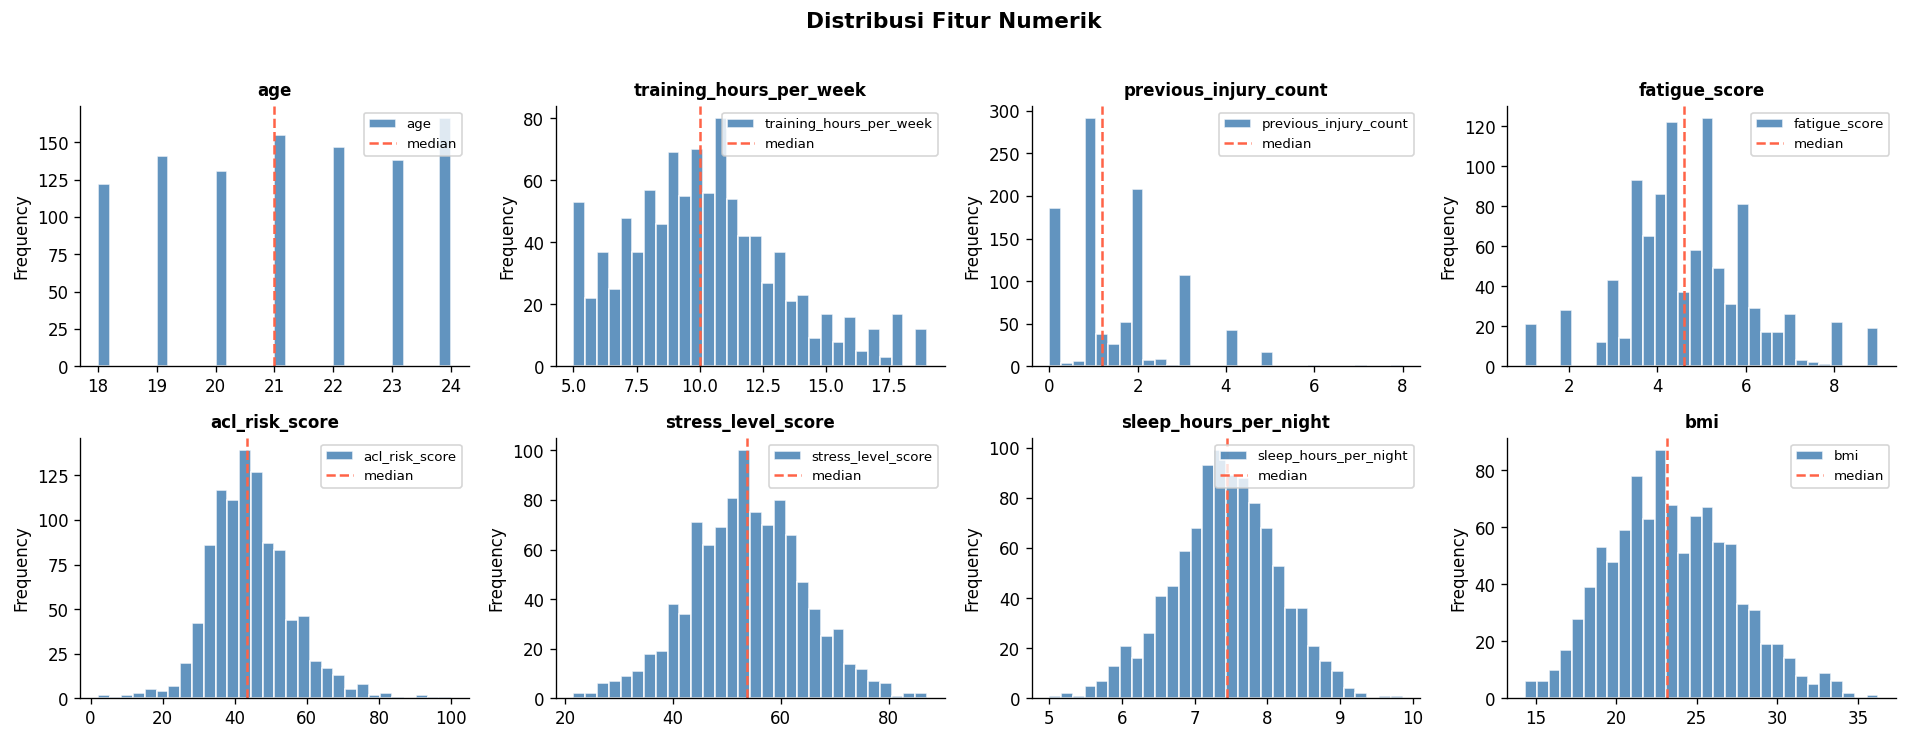

In [15]:
# distribusi variabel numerik
num_plot_cols = [
    c for c in ['age', 'training_hours_per_week', 'previous_injury_count',
                'fatigue_score', 'acl_risk_score', 'stress_level_score',
                'sleep_hours_per_night', 'bmi']
    if c in df_model.columns
]

n = len(num_plot_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_plot_cols):
    ax = axes[i]
    df_model[col].plot(kind='hist', bins=30, ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df_model[col].median(), color='tomato', linestyle='--', linewidth=1.5, label='median')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

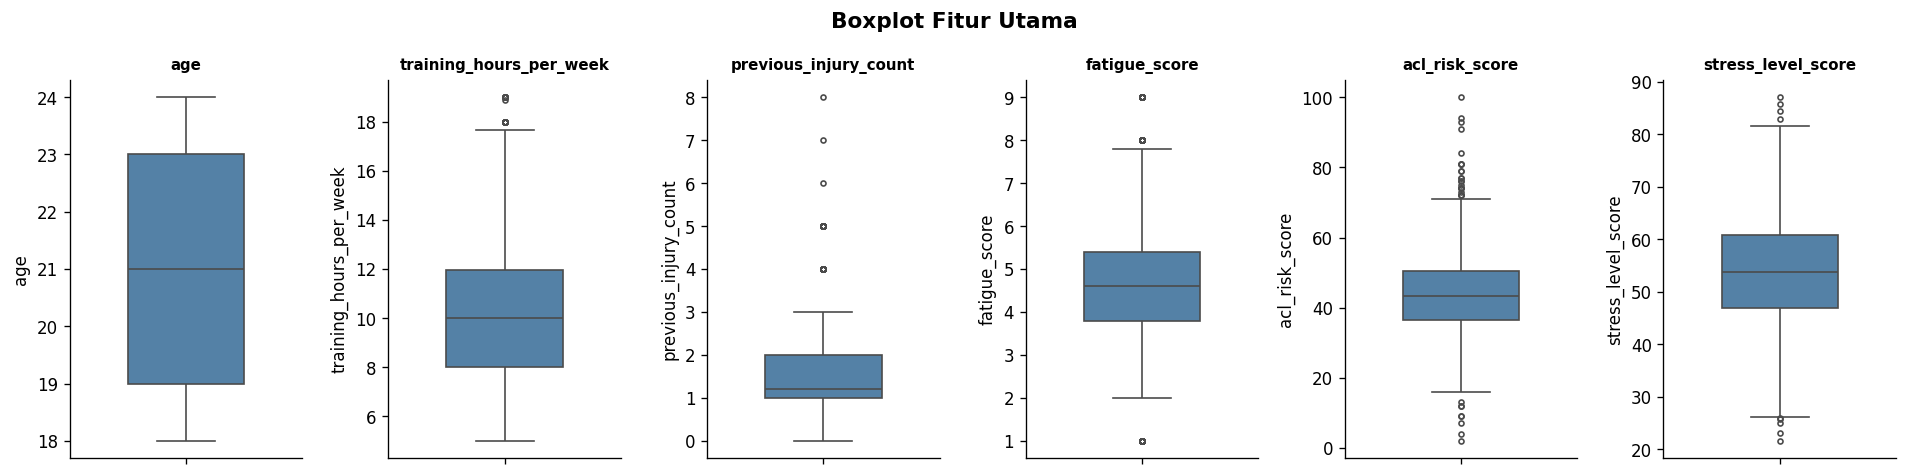

In [16]:
# boxplot untuk mendeteksi outlier
fig, axes = plt.subplots(1, min(6, len(num_plot_cols)), figsize=(16, 4))
if len(num_plot_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_plot_cols[:6]):
    sns.boxplot(y=df_model[col], ax=axes[i], color='steelblue', width=0.5, fliersize=3)
    axes[i].set_title(col, fontsize=9, fontweight='bold')

plt.suptitle('Boxplot Fitur Utama', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

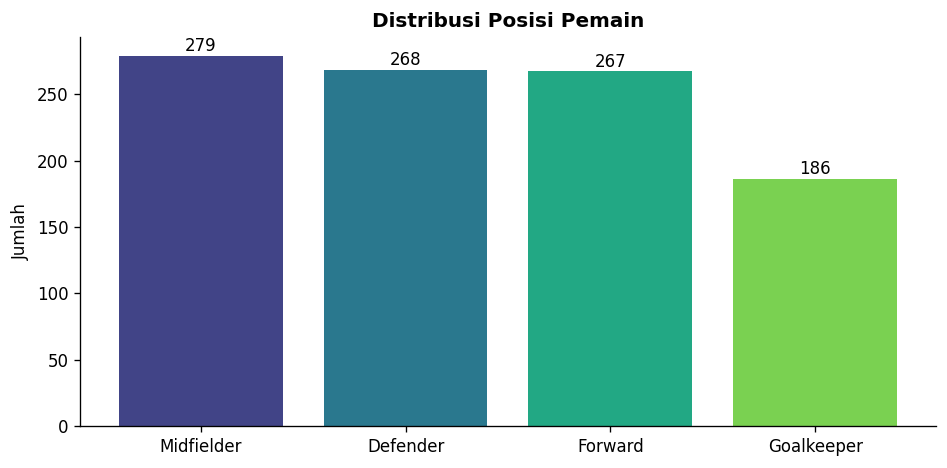

In [17]:
# distribusi posisi
if 'position' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    pos_counts = df['position'].value_counts()
    bars = ax.bar(pos_counts.index, pos_counts.values, color=sns.color_palette('viridis', len(pos_counts)))
    for bar, val in zip(bars, pos_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', fontsize=10)
    ax.set_title('Distribusi Posisi Pemain', fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah')
    plt.tight_layout()
    plt.show()

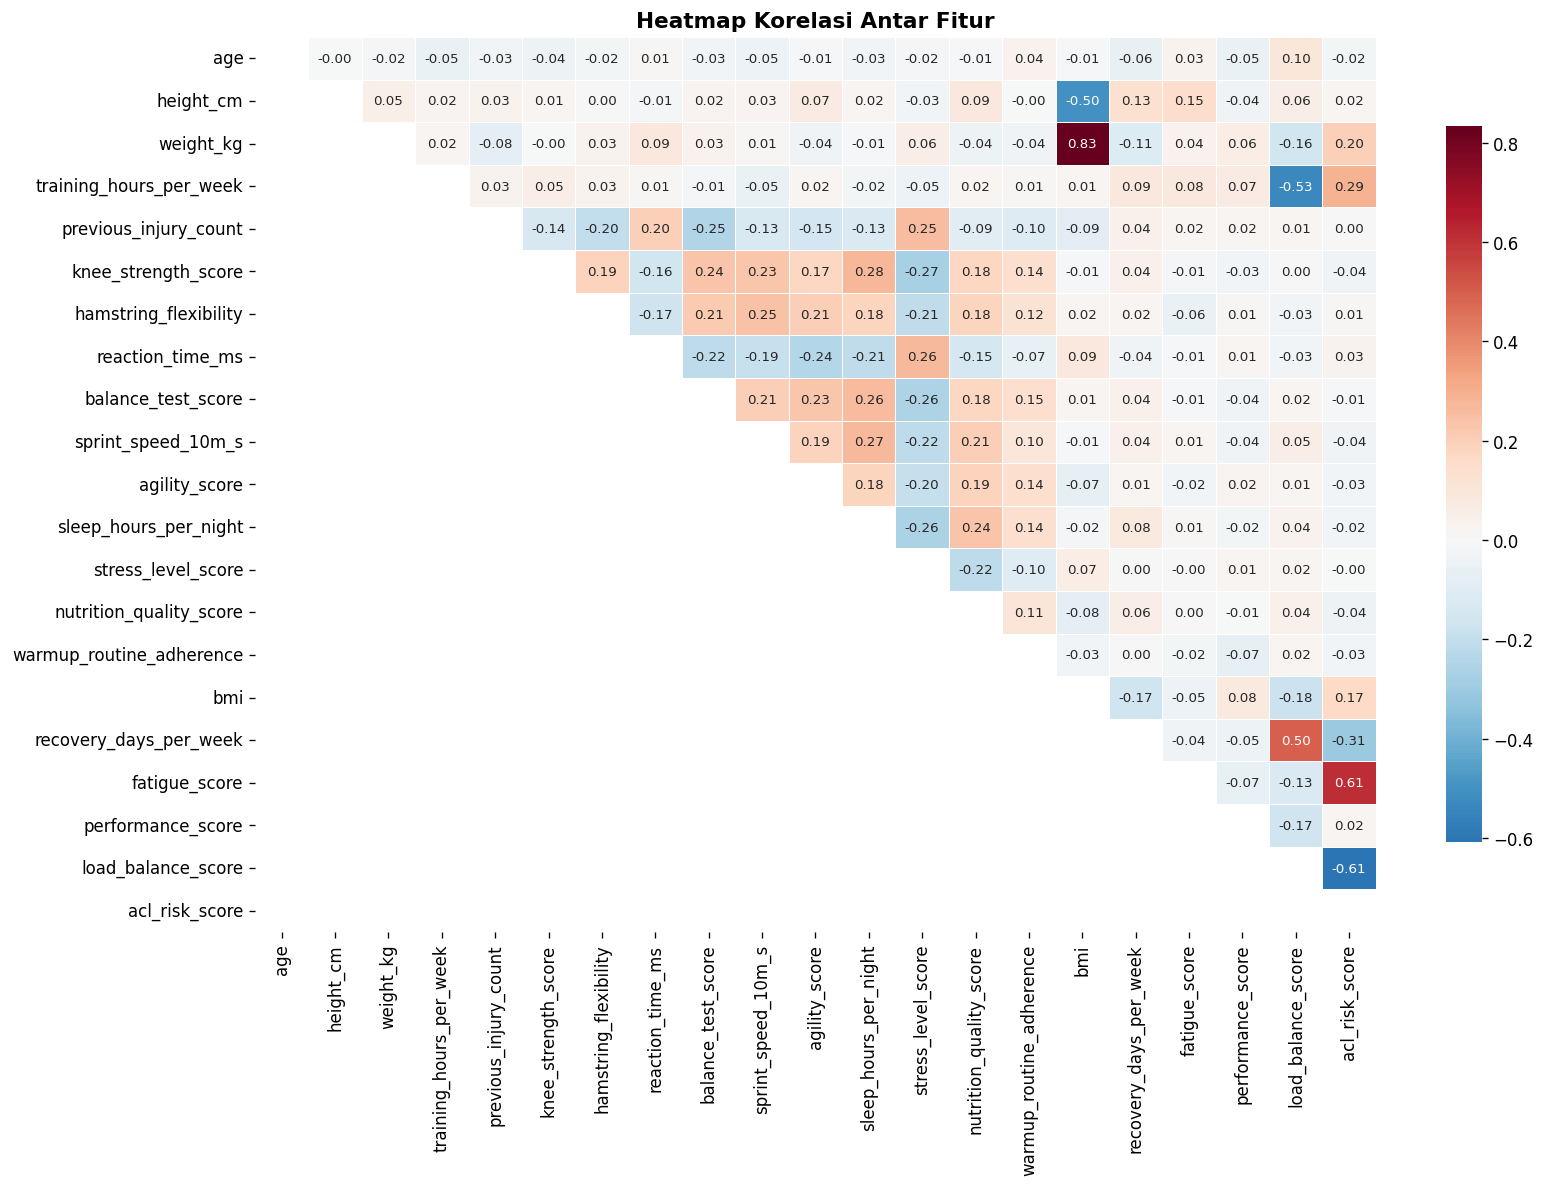

In [18]:
# heatmap korelasi
corr_cols = [c for c in feature_cols if df_model[c].nunique() > 5]
corr_matrix = df_model[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix, mask=~mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.4, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

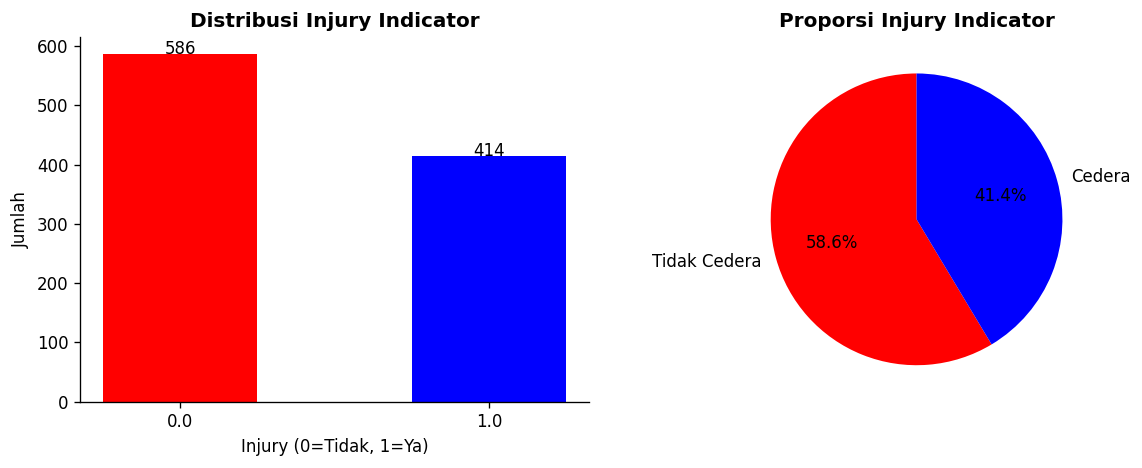

In [19]:
# distribusi injury indicator
if 'injury_indicator' in df_model.columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Bar chart
    counts = df_model['injury_indicator'].value_counts().sort_index()
    axes[0].bar(counts.index.astype(str), counts.values, color=['red', 'blue'], width=0.5)
    axes[0].set_title('Distribusi Injury Indicator', fontweight='bold')
    axes[0].set_xlabel('Injury (0=Tidak, 1=Ya)')
    axes[0].set_ylabel('Jumlah')
    for bar, val in zip(axes[0].patches, counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha='center', fontsize=10)

    # Pie chart
    axes[1].pie(counts.values, labels=['Tidak Cedera', 'Cedera'],
                colors=['red', 'blue'], autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Proporsi Injury Indicator', fontweight='bold')

    plt.tight_layout()
    plt.show()

## Seleksi Fitur & Reduksi Dimensi

In [20]:
# drop fitur dengan varians sangat rendah
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_scaled)
low_var_mask = vt.get_support()
low_var_cols = [c for c, keep in zip(feature_cols, low_var_mask) if not keep]

print("Fitur dengan varians rendah (akan di-drop):", low_var_cols)

X_selected = X_scaled[:, low_var_mask]
selected_cols = [c for c, keep in zip(feature_cols, low_var_mask) if keep]

print(f"\nFitur terpilih ({len(selected_cols)}):")
print(selected_cols)

Fitur dengan varians rendah (akan di-drop): []

Fitur terpilih (23):
['age', 'height_cm', 'weight_kg', 'training_hours_per_week', 'previous_injury_count', 'knee_strength_score', 'hamstring_flexibility', 'reaction_time_ms', 'balance_test_score', 'sprint_speed_10m_s', 'agility_score', 'sleep_hours_per_night', 'stress_level_score', 'nutrition_quality_score', 'warmup_routine_adherence', 'injury_indicator', 'bmi', 'recovery_days_per_week', 'fatigue_score', 'performance_score', 'load_balance_score', 'acl_risk_score', 'position_enc']


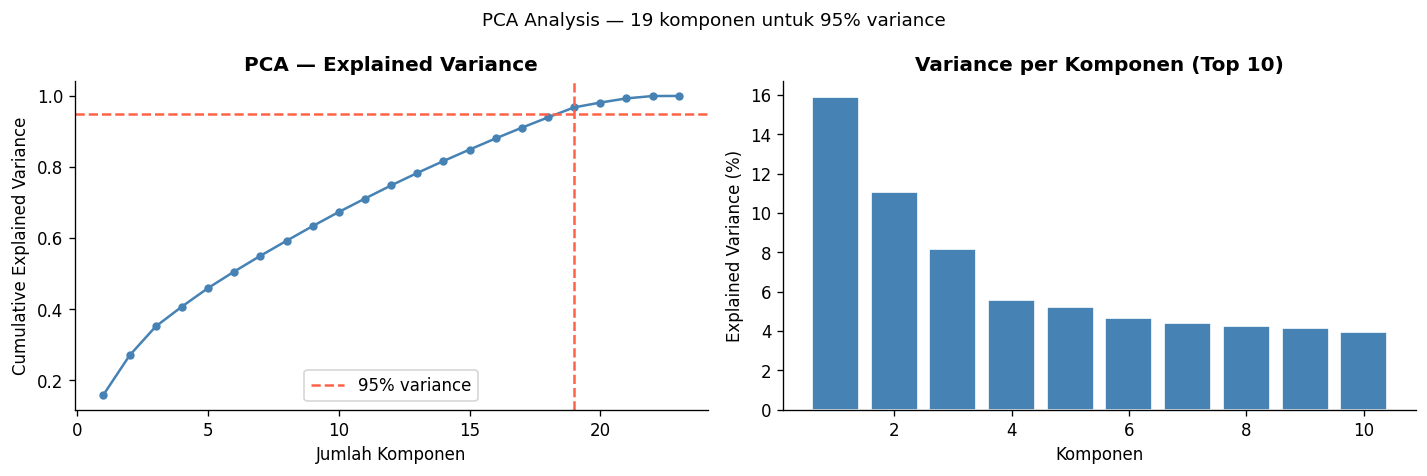

Komponen untuk 95% variance: 19


In [21]:
# PCA analysis
pca_full = PCA(random_state=42)
pca_full.fit(X_selected)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafik 1: Cumulative Explained Variance
axes[0].plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4, color='steelblue')
axes[0].axhline(0.95, color='tomato', linestyle='--', label='95% variance')
axes[0].axvline(n_components_95, color='tomato', linestyle='--')
axes[0].set_xlabel('Jumlah Komponen')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA — Explained Variance', fontweight='bold')
axes[0].legend()

# Tentukan jumlah batas komponen yang ingin diplot (maksimal 10)
n_top_components = min(10, len(pca_full.explained_variance_ratio_))

axes[1].bar(range(1, n_top_components + 1),
            pca_full.explained_variance_ratio_[:n_top_components] * 100,
            color='steelblue', edgecolor='white')
axes[1].set_xlabel('Komponen')
axes[1].set_ylabel('Explained Variance (%)')
axes[1].set_title(f'Variance per Komponen (Top {n_top_components})', fontweight='bold')

plt.suptitle(f'PCA Analysis — {n_components_95} komponen untuk 95% variance', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Komponen untuk 95% variance: {n_components_95}")

In [22]:
# PCA 2D dan 3D untuk visualisasi cluster
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_selected)

pca_3d = PCA(n_components=3, random_state=42)
X_pca3d = pca_3d.fit_transform(X_selected)

print(f"X_pca shape    : {X_pca.shape}")
print(f"X_pca3d shape  : {X_pca3d.shape}")
print(f"Explained variance 2D: {pca_2d.explained_variance_ratio_.sum():.3f}")
print(f"Explained variance 3D: {pca_3d.explained_variance_ratio_.sum():.3f}")

X_cluster = X_selected.copy()

X_pca shape    : (1000, 2)
X_pca3d shape  : (1000, 3)
Explained variance 2D: 0.270
Explained variance 3D: 0.351


## Clustering: K-Means & DBSCAN

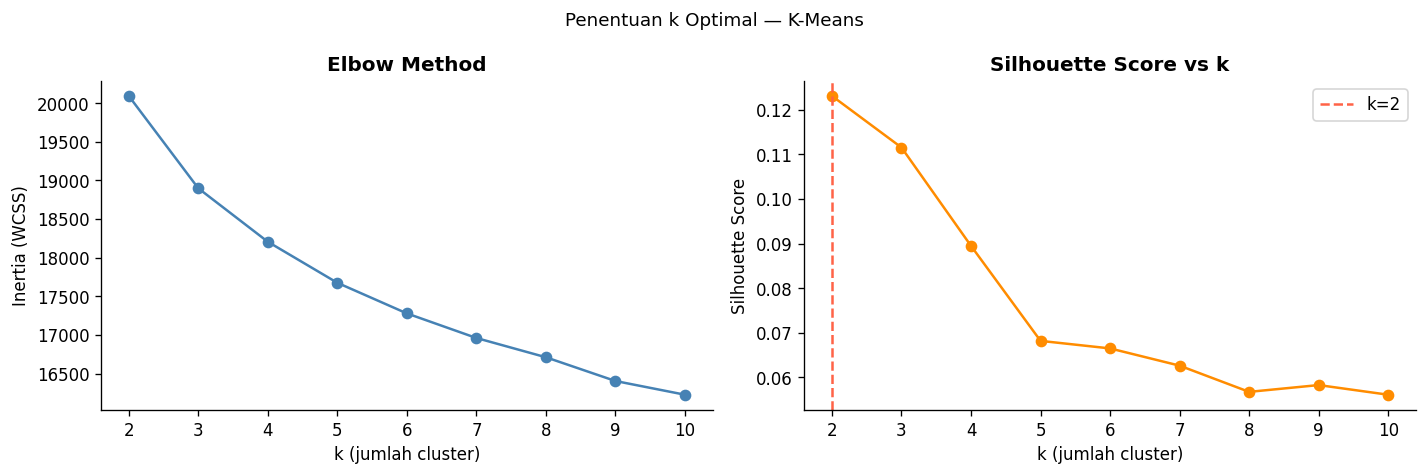

k optimal (silhouette tertinggi): 2
Silhouette score terbaik: 0.1231


In [23]:
# elbow method
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_, sample_size=min(1000, len(X_cluster))))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('k (jumlah cluster)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('k (jumlah cluster)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xticks(list(k_range))

best_k = k_range[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='tomato', linestyle='--', label=f'k={best_k}')
axes[1].legend()

plt.suptitle('Penentuan k Optimal — K-Means', fontsize=11)
plt.tight_layout()
plt.show()

print(f"k optimal (silhouette tertinggi): {best_k}")
print(f"Silhouette score terbaik: {max(sil_scores):.4f}")

In [24]:
# K-Means Fitting
K_OPTIMAL = best_k

kmeans = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=20, max_iter=500, random_state=42)
kmeans.fit(X_cluster)

df['cluster_kmeans'] = kmeans.labels_

print(f"K-Means selesai dengan k={K_OPTIMAL}")
print(f"Inertia final: {kmeans.inertia_:.4f}")
print("\nDistribusi cluster K-Means:")
print(df['cluster_kmeans'].value_counts().sort_index())

K-Means selesai dengan k=2
Inertia final: 20094.0071

Distribusi cluster K-Means:
cluster_kmeans
0    561
1    439
Name: count, dtype: int64


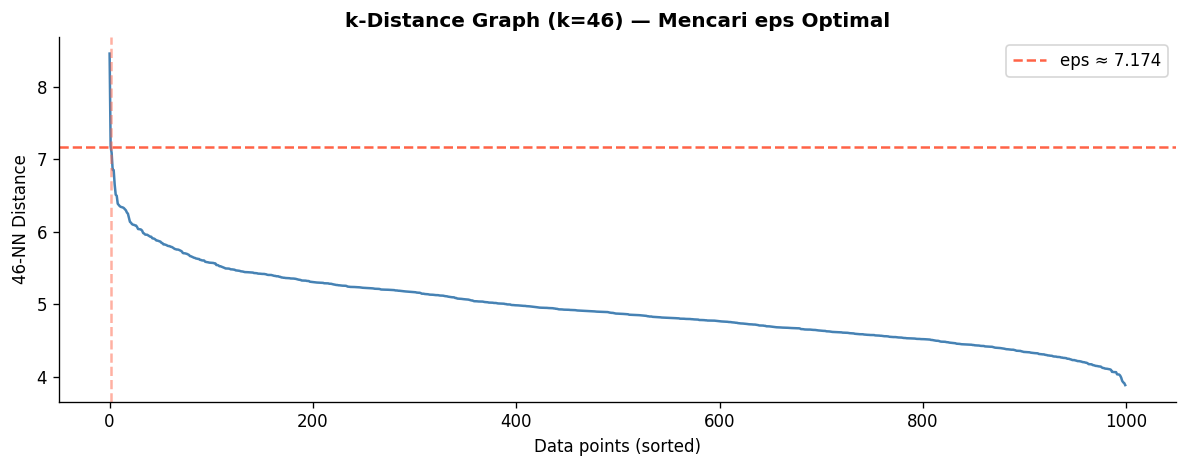

Estimasi eps dari k-distance graph: 7.1744


In [25]:
# DBSCAN — k-distance graph untuk menentukan eps
k_neighbors = 2 * X_cluster.shape[1]
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_cluster)
distances, _ = nbrs.kneighbors(X_cluster)
k_dist = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color='steelblue', linewidth=1.5)
ax.set_xlabel('Data points (sorted)')
ax.set_ylabel(f'{k_neighbors}-NN Distance')
ax.set_title(f'k-Distance Graph (k={k_neighbors}) — Mencari eps Optimal', fontweight='bold')

# estimasi knee point
knee_idx = np.argmax(np.diff(k_dist, 2)) + 1
eps_estimate = k_dist[knee_idx]
ax.axhline(eps_estimate, color='tomato', linestyle='--', label=f'eps ≈ {eps_estimate:.3f}')
ax.axvline(knee_idx, color='tomato', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Estimasi eps dari k-distance graph: {eps_estimate:.4f}")

In [26]:
# DBSCAN Fitting
EPS = round(eps_estimate, 3)
MIN_SAMPLES = k_neighbors

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric='euclidean', n_jobs=-1)
db_labels = dbscan.fit_predict(X_cluster)

df['cluster_dbscan'] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN selesai")
print(f"  eps={EPS}, min_samples={MIN_SAMPLES}")
print(f"  Jumlah cluster : {n_clusters_db}")
print(f"  Noise points   : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")
print("\nDistribusi cluster DBSCAN:")
print(pd.Series(db_labels).value_counts().sort_index())

DBSCAN selesai
  eps=7.174, min_samples=46
  Jumlah cluster : 1
  Noise points   : 0 (0.0%)

Distribusi cluster DBSCAN:
0    1000
Name: count, dtype: int64


## Evaluasi & Validasi Hasil Clustering

In [27]:
# metrik evaluasi
# K-Means
sil_km = silhouette_score(X_cluster, df['cluster_kmeans'], sample_size=min(1000, len(X_cluster)), random_state=42)
dbi_km = davies_bouldin_score(X_cluster, df['cluster_kmeans'])

# DBSCAN (hanya non-noise)
db_mask = df['cluster_dbscan'] != -1
if db_mask.sum() > 10 and len(set(df.loc[db_mask, 'cluster_dbscan'])) > 1:
    sil_db = silhouette_score(X_cluster[db_mask], df.loc[db_mask, 'cluster_dbscan'],
                               sample_size=min(1000, db_mask.sum()), random_state=42)
    dbi_db = davies_bouldin_score(X_cluster[db_mask], df.loc[db_mask, 'cluster_dbscan'])
else:
    sil_db, dbi_db = np.nan, np.nan

metrics = pd.DataFrame({
    'Metrik': ['Jumlah Cluster', 'Silhouette Score', 'Davies-Bouldin Index', 'Noise Points'],
    'K-Means': [K_OPTIMAL, f"{sil_km:.4f}", f"{dbi_km:.4f}", 0],
    'DBSCAN': [n_clusters_db, f"{sil_db:.4f}" if not np.isnan(sil_db) else 'N/A',
               f"{dbi_db:.4f}" if not np.isnan(dbi_db) else 'N/A', n_noise]
})

print(metrics.to_string(index=False))

              Metrik K-Means DBSCAN
      Jumlah Cluster       2      1
    Silhouette Score  0.1231    N/A
Davies-Bouldin Index  2.5636    N/A
        Noise Points       0      0


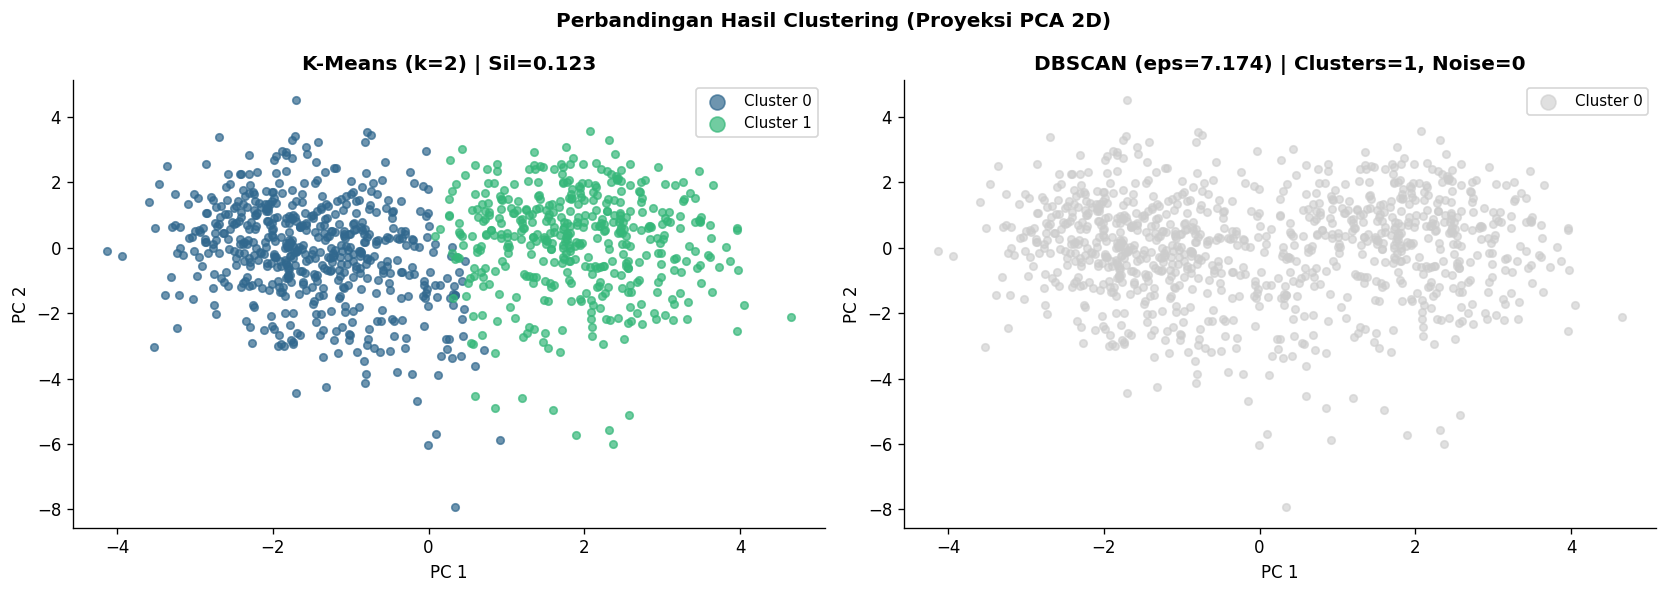

In [28]:
# scatter plot K-Means vs DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Palette
palette_km = sns.color_palette('viridis', K_OPTIMAL)
n_db_clusters = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
palette_db = ['#cccccc'] + list(sns.color_palette('viridis', n_db_clusters))

# K-Means scatter
for cl in sorted(df['cluster_kmeans'].unique()):
    mask = df['cluster_kmeans'] == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[palette_km[cl]], s=20, alpha=0.7, label=f'Cluster {cl}')
axes[0].set_title(f'K-Means (k={K_OPTIMAL}) | Sil={sil_km:.3f}', fontweight='bold')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].legend(markerscale=2, fontsize=9)

# DBSCAN scatter
labels_sorted = sorted(df['cluster_dbscan'].unique())
for i, cl in enumerate(labels_sorted):
    mask = df['cluster_dbscan'] == cl
    color = palette_db[i]
    label = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color], s=20, alpha=0.6, label=label)
axes[1].set_title(f'DBSCAN (eps={EPS}) | Clusters={n_clusters_db}, Noise={n_noise}', fontweight='bold')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].legend(markerscale=2, fontsize=9)

plt.suptitle('Perbandingan Hasil Clustering (Proyeksi PCA 2D)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

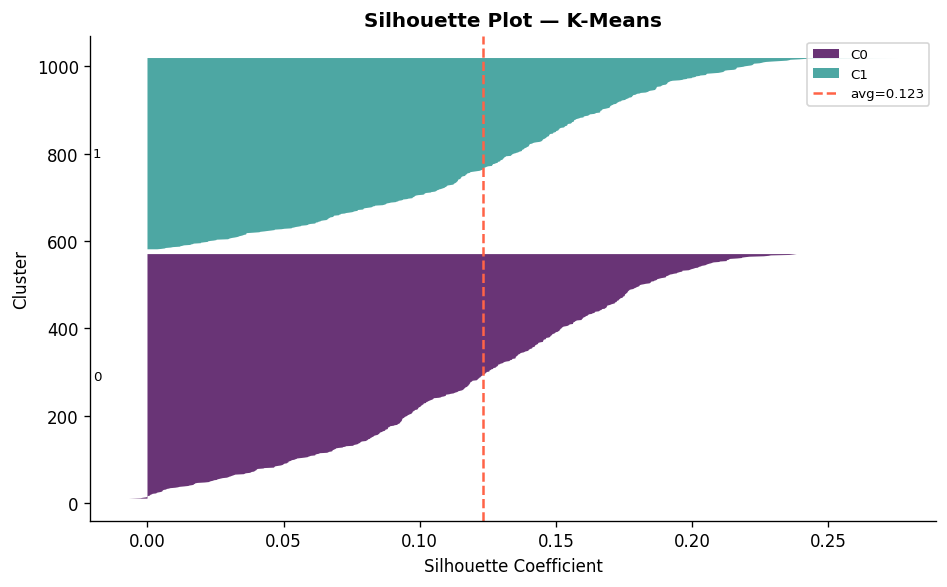

In [29]:
# silhouette plot per Sample (K-Means)
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X_cluster, df['cluster_kmeans'])
y_lower = 10

fig, ax = plt.subplots(figsize=(8, 5))
for cl in range(K_OPTIMAL):
    cl_sil = np.sort(sil_vals[df['cluster_kmeans'] == cl])
    size = len(cl_sil)
    y_upper = y_lower + size
    color = plt.cm.viridis(cl / K_OPTIMAL)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil, facecolor=color, alpha=0.8, label=f'C{cl}')
    ax.text(-0.02, y_lower + size/2, str(cl), fontsize=8, va='center')
    y_lower = y_upper + 10

ax.axvline(sil_km, color='tomato', linestyle='--', linewidth=1.5, label=f'avg={sil_km:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — K-Means', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## Profiling Cluster & Interpretasi Risiko

In [30]:
# statistik per Cluster
profile_cols = [c for c in selected_cols if c in df.columns and c not in ['source', 'position']]

cluster_profile = df.groupby('cluster_kmeans')[profile_cols].agg(['mean', 'median']).round(3)
print("Profil statistik per cluster (K-Means):")
cluster_profile

Profil statistik per cluster (K-Means):


age        height_cm        weight_kg         \
                  mean median      mean median      mean median   
cluster_kmeans                                                    
0               21.119   21.0   178.654  178.0    74.271   73.0   
1               21.171   21.0   177.362  177.0    73.843   74.0   

               training_hours_per_week         previous_injury_count         \
                                  mean  median                  mean median   
cluster_kmeans                                                                
0                               10.305  10.000                 1.151    1.0   
1                               10.120  10.026                 2.002    2.0   

               knee_strength_score         hamstring_flexibility          \
                              mean  median                  mean  median   
cluster_kmeans                                                             
0                           77.459  77.460                81.598  81.269   
1                           71.940  72.111                76.207  76.037   

               reaction_time_ms  ... injury_indicator     bmi          \
                           mean  ...           median    mean  median   
cluster_kmeans                   ...                                    
0                       241.588  ...              0.0  23.400  23.184   
1                       259.561  ...              1.0  23.592  23.140   

               recovery_days_per_week        fatigue_score         \
                                 mean median          mean median   
cluster_kmeans                                                      
0                               1.968    2.0         4.689    4.6   
1                               1.886    1.8         4.712    4.6   

               performance_score        load_balance_score         \
                            mean median               mean median   
cluster_kmeans                                                      
0                         74.624   75.0             94.604   95.8   
1                         76.900   76.4             94.083   95.2   

               acl_risk_score        position_enc         
                         mean median         mean median  
cluster_kmeans                                            
0                      43.768   43.0        1.476    1.0  
1                      45.275   44.0        1.476    1.0  

[2 rows x 46 columns]

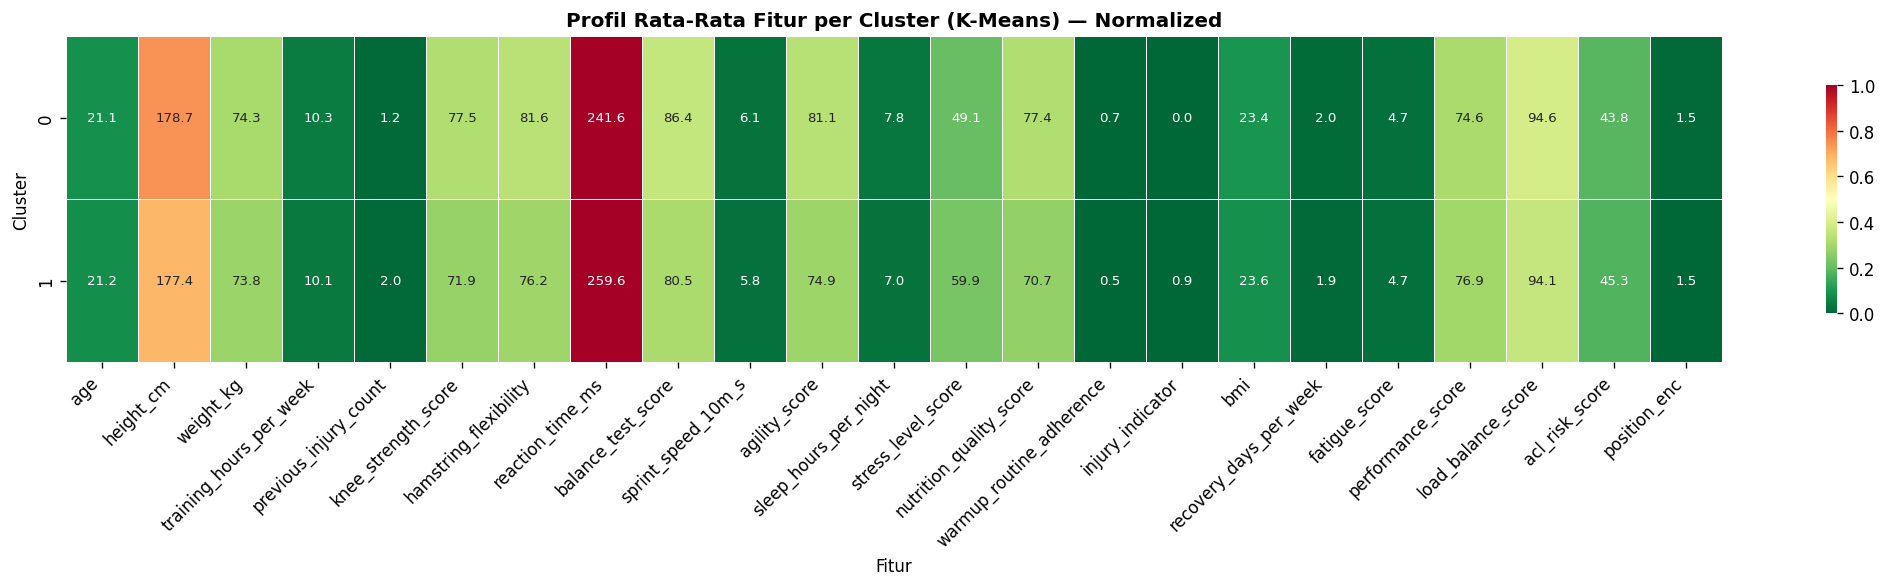

In [31]:
# heatmap profil cluster
cluster_means = df.groupby('cluster_kmeans')[profile_cols].mean()

from sklearn.preprocessing import MinMaxScaler
scaler_vis = MinMaxScaler()
cluster_means_norm = pd.DataFrame(
    scaler_vis.fit_transform(cluster_means.T).T,
    index=cluster_means.index,
    columns=cluster_means.columns
)

fig, ax = plt.subplots(figsize=(min(18, len(profile_cols)*0.9 + 2), 5))
sns.heatmap(cluster_means_norm, annot=cluster_means.round(1), fmt='.1f',
            cmap='RdYlGn_r', linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Profil Rata-Rata Fitur per Cluster (K-Means) — Normalized', fontweight='bold')
ax.set_xlabel('Fitur')
ax.set_ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
# penamaan cluster berdasarkan profil
# menentukan fitur kunci untuk penamaan
key_features = []
if 'previous_injury_count' in cluster_means.columns:
    key_features.append('previous_injury_count')
if 'injury_indicator' in cluster_means.columns:
    key_features.append('injury_indicator')
if 'fatigue_score' in cluster_means.columns:
    key_features.append('fatigue_score')
if 'acl_risk_score' in cluster_means.columns:
    key_features.append('acl_risk_score')
if 'stress_level_score' in cluster_means.columns:
    key_features.append('stress_level_score')

print("Rata-rata fitur kunci per cluster:")
if key_features:
    print(cluster_means[key_features].round(3))
    print()

    # rkor risiko agregat
    risk_cols = [c for c in key_features if c in cluster_means_norm.columns]
    cluster_means_norm['risk_score'] = cluster_means_norm[risk_cols].mean(axis=1)
    print("Skor risiko agregat (normalized):")
    print(cluster_means_norm['risk_score'].sort_values(ascending=False))

    # menentukan label
    risk_order = cluster_means_norm['risk_score'].sort_values(ascending=False)
    n_cl = len(risk_order)
    labels_preset = {
        3: ['Risiko Tinggi', 'Risiko Sedang', 'Risiko Rendah'],
        4: ['Risiko Sangat Tinggi', 'Risiko Tinggi', 'Risiko Sedang', 'Risiko Rendah'],
        2: ['Risiko Tinggi', 'Risiko Rendah']
    }
    label_list = labels_preset.get(n_cl, [f'Cluster {i}' for i in range(n_cl)])

    cluster_label_map = {idx: label for idx, label in zip(risk_order.index, label_list)}
    df['cluster_label'] = df['cluster_kmeans'].map(cluster_label_map)

    print("\nLabel cluster:")
    for k, v in cluster_label_map.items():
        print(f"Cluster {k} = {v}")
else:
    df['cluster_label'] = df['cluster_kmeans'].map(lambda x: f'Cluster {x}')

Rata-rata fitur kunci per cluster:
                previous_injury_count  injury_indicator  fatigue_score  \
cluster_kmeans                                                           
0                               1.151             0.014          4.689   
1                               2.002             0.925          4.712   

                acl_risk_score  stress_level_score  
cluster_kmeans                                      
0                       43.768              49.109  
1                       45.275              59.943  

Skor risiko agregat (normalized):
cluster_kmeans
1    0.085310
0    0.081682
Name: risk_score, dtype: float64

Label cluster:
Cluster 1 = Risiko Tinggi
Cluster 0 = Risiko Rendah


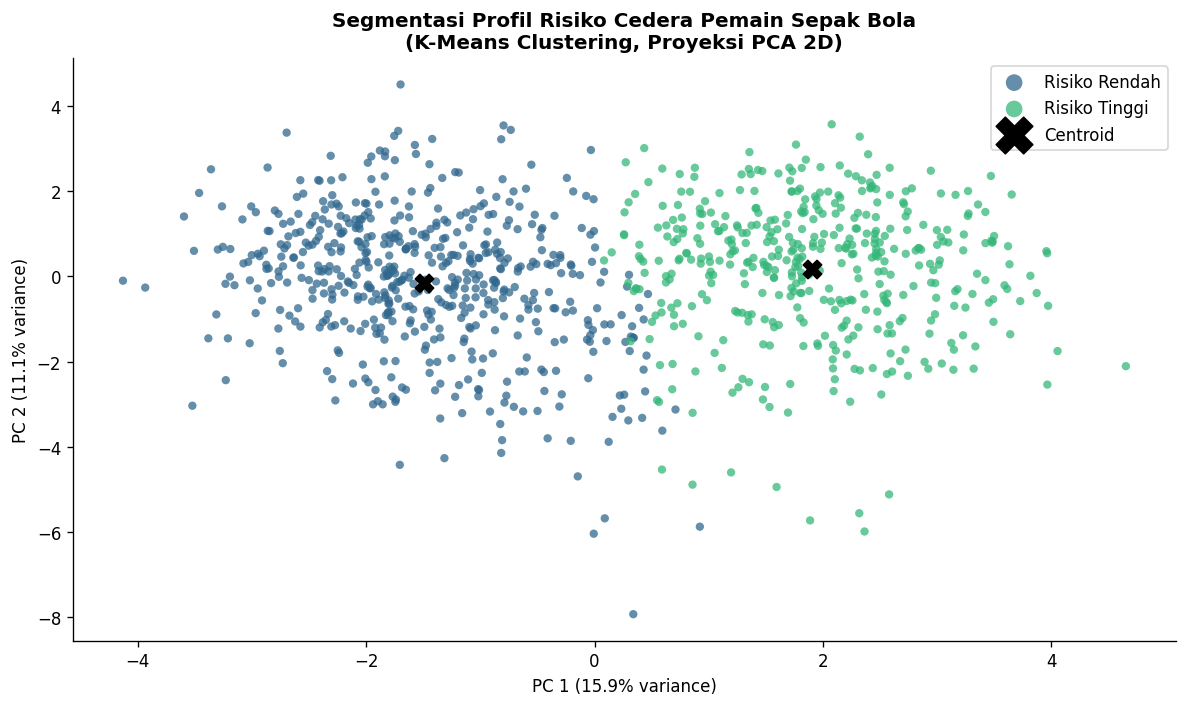

In [33]:
# visualisasi final dengan label
fig, ax = plt.subplots(figsize=(10, 6))
labels_unique = df['cluster_label'].unique()
palette = dict(zip(sorted(labels_unique), sns.color_palette('viridis', len(labels_unique))))

for label in sorted(labels_unique):
    mask = df['cluster_label'] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[palette[label]], s=25, alpha=0.75, label=label, edgecolors='none')

km_centers_pca = pca_2d.transform(kmeans.cluster_centers_)

ax.scatter(km_centers_pca[:, 0], km_centers_pca[:, 1],
           c='black', marker='X', s=120, zorder=5, label='Centroid')

ax.set_title('Segmentasi Profil Risiko Cedera Pemain Sepak Bola\n(K-Means Clustering, Proyeksi PCA 2D)',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(markerscale=2, fontsize=10, loc='best')
plt.tight_layout()
plt.show()

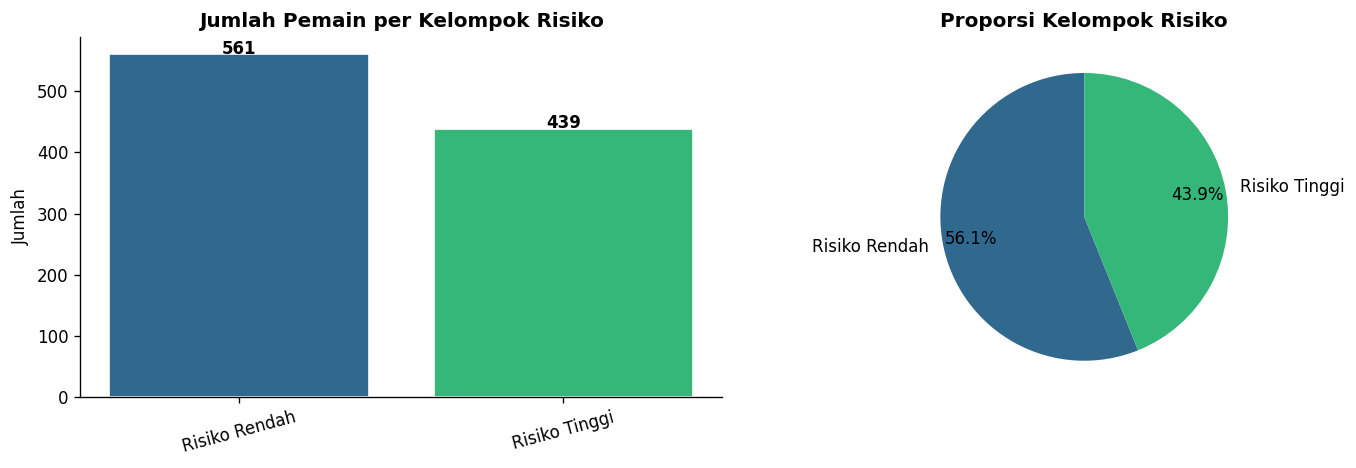

In [34]:
# distribusi Cluster & Label
label_counts = df['cluster_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = sns.color_palette('viridis', len(label_counts))

bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Jumlah Pemain per Kelompok Risiko', fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(label_counts.values, labels=label_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.8)
axes[1].set_title('Proporsi Kelompok Risiko', fontweight='bold')

plt.tight_layout()
plt.show()

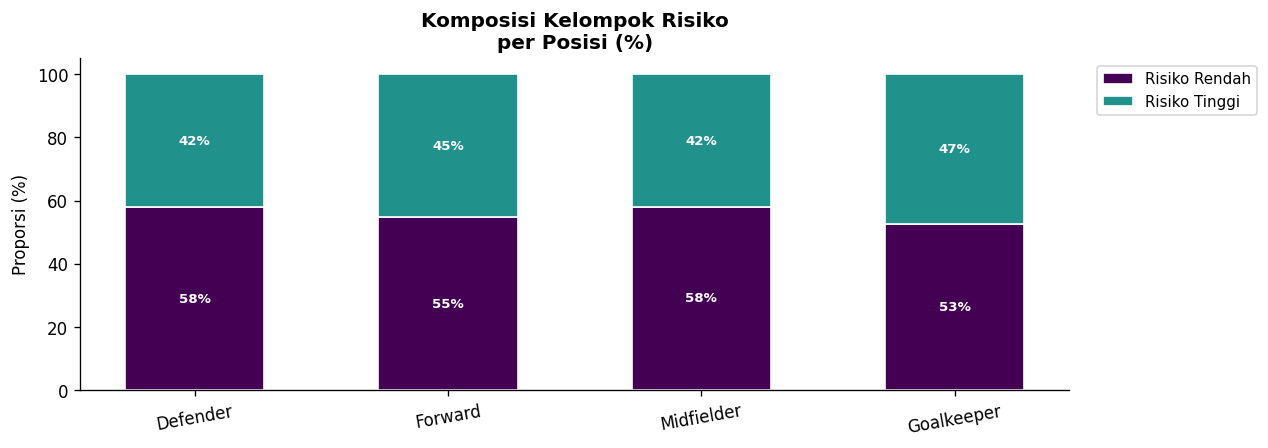

In [35]:
# persebaran posisi pemain terhadap kelompok risiko cedera & ACL
if 'acl_risk_score' not in df.columns or 'position' not in df.columns:
    print("Kolom acl_risk_score atau position tidak ditemukan.")
else:
    label_priority = ['Risiko Rendah', 'Risiko Tinggi']
    risk_order = sorted(
        df['cluster_label'].unique(),
        key=lambda x: label_priority.index(x) if x in label_priority else 99
    )

    pos_order = df.groupby('position')['acl_risk_score'].mean().sort_values(ascending=False).index.tolist()

    risk_palette = {
        'Risiko Rendah': '#440154',
        'Risiko Sedang': '#3b528b',
        'Risiko Tinggi': '#21918c',
        'Risiko Sangat Tinggi': '#5ec962'
    }

    fig = plt.figure(figsize=(25, 14))
    gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)

    ax2 = fig.add_subplot(gs[1, 0])
    ct_pos = pd.crosstab(df['position'], df['cluster_label'])
    ct_pos = ct_pos.loc[pos_order, [r for r in risk_order if r in ct_pos.columns]]
    ct_pos_pct = ct_pos.div(ct_pos.sum(axis=1), axis=0) * 100

    bottom = np.zeros(len(ct_pos_pct))
    for risk_label in [r for r in risk_order if r in ct_pos_pct.columns]:
        vals = ct_pos_pct[risk_label].values
        bars = ax2.bar(ct_pos_pct.index, vals, bottom=bottom,
                       color=risk_palette.get(risk_label, '#999'), label=risk_label,
                       edgecolor='white', width=0.55)
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 0:
                ax2.text(bar.get_x() + bar.get_width() / 2, bot + val / 2,
                         f'{val:.0f}%', ha='center', va='center',
                         fontsize=8, fontweight='bold', color='white')
        bottom += vals
    ax2.set_title('Komposisi Kelompok Risiko\nper Posisi (%)', fontweight='bold')
    ax2.set_ylabel('Proporsi (%)')
    ax2.set_ylim(0, 105)
    ax2.tick_params(axis='x', rotation=10)
    ax2.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)

In [36]:
print(df.columns.tolist())

['age', 'height_cm', 'weight_kg', 'position', 'training_hours_per_week', 'previous_injury_count', 'knee_strength_score', 'hamstring_flexibility', 'reaction_time_ms', 'balance_test_score', 'sprint_speed_10m_s', 'agility_score', 'sleep_hours_per_night', 'stress_level_score', 'nutrition_quality_score', 'warmup_routine_adherence', 'injury_indicator', 'bmi', 'source', 'recovery_days_per_week', 'fatigue_score', 'performance_score', 'load_balance_score', 'acl_risk_score', 'position_enc', 'cluster_kmeans', 'cluster_dbscan', 'cluster_label']


JUMLAH PEMAIN PER POSISI DI SETIAP KELOMPOK RISIKO:
position       Defender  Forward  Goalkeeper  Midfielder
cluster_label                                           
Risiko Rendah       155      146          98         162
Risiko Tinggi       113      121          88         117


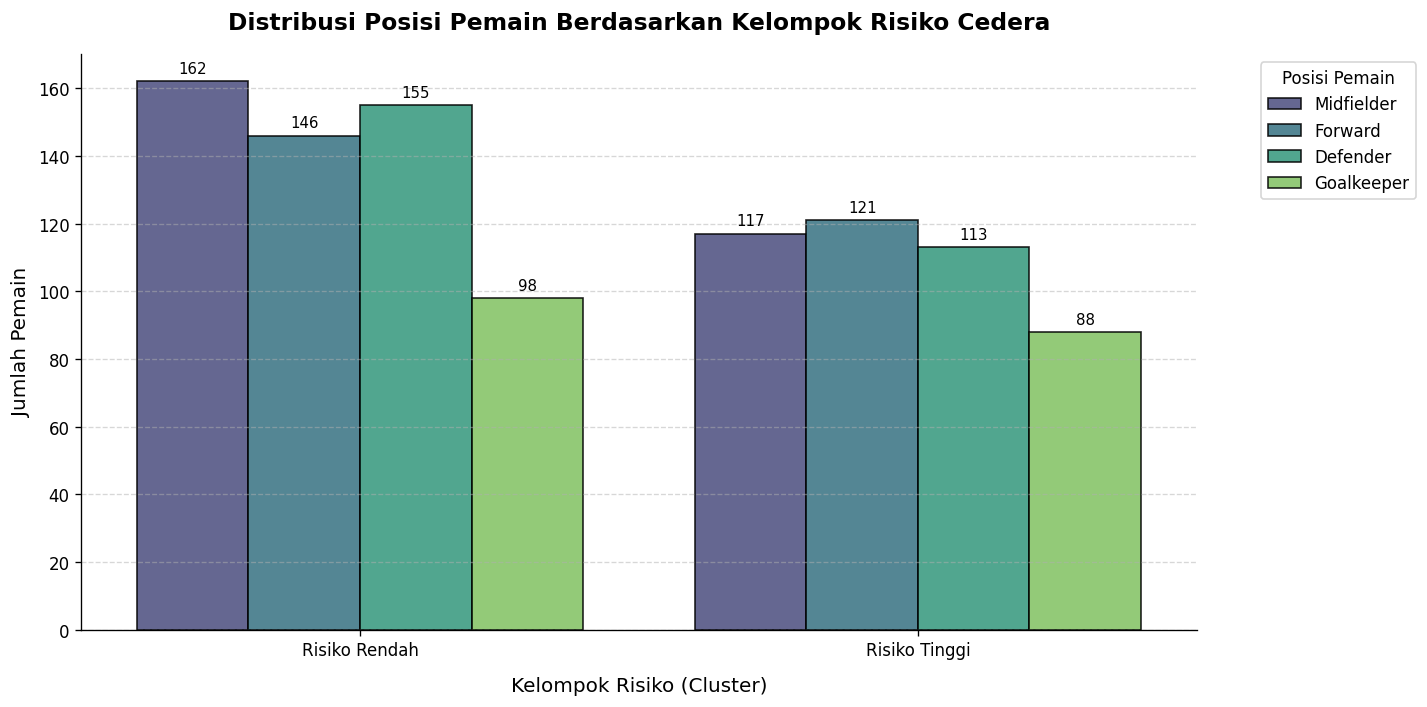

In [37]:
# Menentukan nama kolom secara definitif
kolom_cluster = 'cluster_label'
kolom_posisi = 'position'
print("JUMLAH PEMAIN PER POSISI DI SETIAP KELOMPOK RISIKO:")

# 1. Membuat tabel kontingensi (cross-tabulation)
tabel_posisi = pd.crosstab(df[kolom_cluster], df[kolom_posisi])
print(tabel_posisi)

# 2. Visualisasi Grafik Batang Berkelompok
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df,
    x=kolom_cluster,
    hue=kolom_posisi,
    palette='viridis',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribusi Posisi Pemain Berdasarkan Kelompok Risiko Cedera', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kelompok Risiko (Cluster)', fontsize=12, labelpad=10)
plt.ylabel('Jumlah Pemain', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Posisi Pemain', bbox_to_anchor=(1.05, 1), loc='upper left')

# Menampilkan angka di atas setiap batang grafik
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='baseline',
            fontsize=9, color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()